## Application — Diversified TSMOM Portfolio

### From toy to book
Notebooks 1–2 studied **single-asset** rules. The Moskowitz / Ooi / Pedersen result is
fundamentally **cross-asset**: average many independently trending markets.

### What this notebook does
1. Build per-asset **12m sign** and **multi-horizon score** strategies
2. Form an **equal-weight** portfolio across assets available each month
3. Apply a simple **turnover cost** haircut (10 bps)
4. Optionally **volatility-target** the portfolio to 10% annualized

### How to read
- Tables: compare EW buy-and-hold vs 12m vs score (gross / net / vol-targeted)
- Charts: equity curves, drawdowns, per-asset contribution
- Closing text: what is publishable vs what is a caveat

Universe: SPY, BIL, IEF, TLT, GLD, BTC-USD (ETF proxies + crypto — **not** the futures panel).


In [1]:
import pandas as pd
from IPython.display import display, Markdown

from helpers.data_utils import load_monthly_panel
from helpers.signal_utils import trailing_return, sign_signal, multi_horizon_score
from helpers.backtest_utils import (
    position_from_signal, strategy_returns, perf_stats, compare_perf_stats,
    turnover, apply_transaction_costs, equal_weight_portfolio,
    volatility_target_returns,
)
from helpers.plot_utils import (
    plot_cumulative_comparison, plot_drawdown_comparison, plot_metric_bars,
)

TICKERS = ["SPY", "BIL", "IEF", "TLT", "GLD", "BTC-USD"]
HORIZONS = [1, 3, 6, 12]
COST_BPS = 10.0
TARGET_VOL = 0.10

px_m, r_m = load_monthly_panel(TICKERS)
display(Markdown(
    f"Loaded `{list(r_m.columns)}`. Coverage differs by asset — EW uses whatever is available each month."
))
display(r_m.describe().T[["count", "mean", "std"]].round(4))


Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216


Loaded `['SPY', 'BIL', 'IEF', 'TLT', 'GLD', 'BTC-USD']`. Coverage differs by asset — EW uses whatever is available each month.

,count,mean,std
SPY,399.0,0.0092,0.0424
BIL,227.0,0.0011,0.0016
IEF,285.0,0.0031,0.0192
TLT,285.0,0.0038,0.0390
GLD,257.0,0.0101,0.0492
BTC-USD,139.0,0.0573,0.2073


### Per-asset signals → strategy returns → portfolio

Pipeline reminder:
$s_{k,t}=\mathrm{sign}(R_{k,t})$, score $=\frac14\sum_k s_{k,t}$,
$p_t=$ lagged signal, asset strategy $=p_t r_t$, portfolio $=$ equal-weight of asset strategies.


In [2]:
signals = {k: sign_signal(trailing_return(r_m, k)) for k in HORIZONS}
sig_12 = signals[12]
score = multi_horizon_score(signals)

pos_12 = position_from_signal(sig_12, lag=1)
pos_score = position_from_signal(score, lag=1)

r_12 = strategy_returns(pos_12, r_m)
r_score = strategy_returns(pos_score, r_m)

port_bh = equal_weight_portfolio(r_m)
port_12 = equal_weight_portfolio(r_12)
port_score = equal_weight_portfolio(r_score)

r_12_net = apply_transaction_costs(r_12, pos_12, cost_bps=COST_BPS)
r_score_net = apply_transaction_costs(r_score, pos_score, cost_bps=COST_BPS)
port_12_net = equal_weight_portfolio(r_12_net)
port_score_net = equal_weight_portfolio(r_score_net)
port_score_vt = volatility_target_returns(port_score_net, target_ann_vol=TARGET_VOL)

stats = compare_perf_stats({
    "EW Buy&Hold": port_bh,
    "EW 12m gross": port_12,
    "EW 12m net": port_12_net,
    "EW Score gross": port_score,
    "EW Score net": port_score_net,
    "EW Score net + 10% VT": port_score_vt,
})
display(Markdown("#### Portfolio performance"))
display(stats.round(4))

turns = pd.Series({
    "12m avg turnover": turnover(pos_12).mean().mean(),
    "Score avg turnover": turnover(pos_score).mean().mean(),
})
display(Markdown("#### Average asset-level monthly turnover $|\Delta p|$"))
display(turns.round(4))


<>:36: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:36: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/jn/y5sznyds3jn3gnk2zpy70gj80000gn/T/ipykernel_62179/3270104595.py:36: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  display(Markdown("#### Average asset-level monthly turnover $|\Delta p|$"))


#### Portfolio performance

,EW Buy&Hold,EW 12m gross,EW 12m net,EW Score gross,EW Score net,EW Score net + 10% VT
CAGR,0.1136,0.1055,0.1071,0.0714,0.0684,0.1021
Ann. Mean,0.1154,0.1082,0.1096,0.0736,0.0708,0.1052
Ann. Vol,0.1222,0.1226,0.1218,0.0957,0.0954,0.1255
Sharpe,0.9448,0.8828,0.8997,0.7696,0.7428,0.8385
Max Drawdown,-0.3867,-0.2255,-0.2276,-0.1705,-0.1764,-0.2034
Hit Rate,0.6216,0.6124,0.6088,0.5969,0.5803,0.5882


#### Average asset-level monthly turnover $|\Delta p|$

12m avg turnover      0.1655
Score avg turnover    0.3991
dtype: float64

### Charts — growth, drawdowns, and who contributes

**What to look for:** diversified 12m should keep Sharpe near buy-and-hold while cutting max DD.
Score should look more defensive (lower DD / vol) with a return tradeoff.


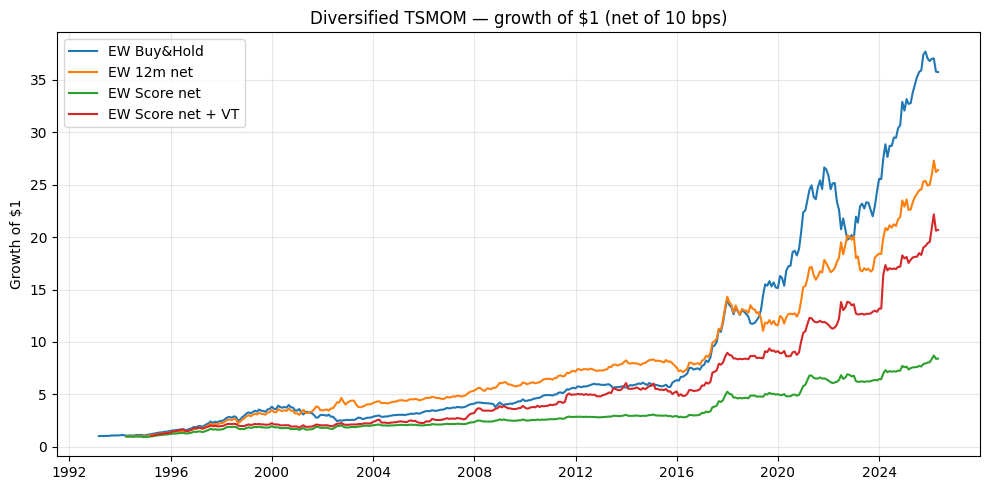

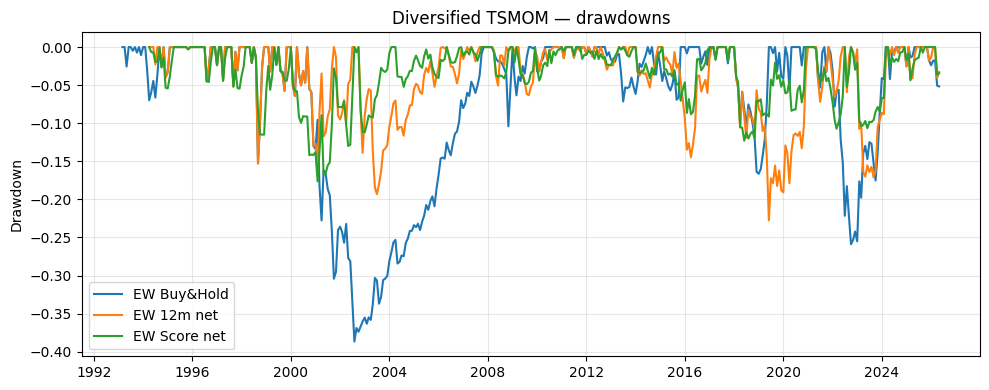

#### Per-asset strategy Sharpe (gross)

,12m,Score
SPY,0.710,0.575
BIL,2.282,2.274
IEF,0.397,0.216
TLT,0.119,0.134
GLD,0.495,0.482
BTC-USD,0.770,0.884


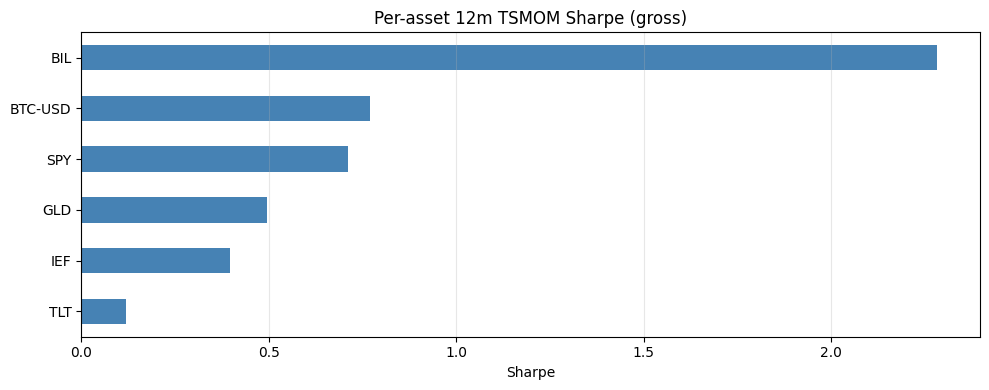

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Per-asset 12m TSMOM Sharpe (gross)'}, xlabel='Sharpe'>)

In [3]:
plot_cumulative_comparison(
    {
        "EW Buy&Hold": port_bh,
        "EW 12m net": port_12_net,
        "EW Score net": port_score_net,
        "EW Score net + VT": port_score_vt,
    },
    title="Diversified TSMOM — growth of $1 (net of 10 bps)",
)
plot_drawdown_comparison(
    {
        "EW Buy&Hold": port_bh,
        "EW 12m net": port_12_net,
        "EW Score net": port_score_net,
    },
    title="Diversified TSMOM — drawdowns",
)

asset_sharpe_12 = r_12.apply(lambda c: perf_stats(c)["Sharpe"]).rename("12m")
asset_sharpe_sc = r_score.apply(lambda c: perf_stats(c)["Sharpe"]).rename("Score")
by_asset = pd.concat([asset_sharpe_12, asset_sharpe_sc], axis=1)
display(Markdown("#### Per-asset strategy Sharpe (gross)"))
display(by_asset.round(3))
plot_metric_bars(
    by_asset["12m"].sort_values(),
    title="Per-asset 12m TSMOM Sharpe (gross)",
    ylabel="Sharpe",
    color="steelblue",
)


### Takeaway


In [4]:
bh_s = float(stats.loc["Sharpe", "EW Buy&Hold"])
bh_dd = float(stats.loc["Max Drawdown", "EW Buy&Hold"])
s12 = float(stats.loc["Sharpe", "EW 12m net"])
dd12 = float(stats.loc["Max Drawdown", "EW 12m net"])
ss = float(stats.loc["Sharpe", "EW Score net"])
dds = float(stats.loc["Max Drawdown", "EW Score net"])

display(Markdown(f'''### Findings (auto-filled)
| Portfolio | Sharpe | Max DD |
|-----------|-------:|-------:|
| EW buy-and-hold | {bh_s:.2f} | {bh_dd:.1%} |
| EW 12m net (10 bps) | {s12:.2f} | {dd12:.1%} |
| EW score net (10 bps) | {ss:.2f} | {dds:.1%} |

**Publishable story:** diversification is the point — EW 12m keeps Sharpe near buy-and-hold while
cutting the left tail. The multi-horizon score is the **defensive sibling** (smaller DD, lower Sharpe).

**Caveats:** ETF/crypto proxy ≠ futures panel; BTC history is short and violent; no short financing;
10 bps is illustrative.

**Next:** `research/03_disagreement.ipynb` (regime meter), `research/04_robustness.ipynb` (stress tests),
`research/05_combo_grid.ipynb` (other ways to merge horizons).
'''))


### Findings (auto-filled)
| Portfolio | Sharpe | Max DD |
|-----------|-------:|-------:|
| EW buy-and-hold | 0.94 | -38.7% |
| EW 12m net (10 bps) | 0.90 | -22.8% |
| EW score net (10 bps) | 0.74 | -17.6% |

**Publishable story:** diversification is the point — EW 12m keeps Sharpe near buy-and-hold while
cutting the left tail. The multi-horizon score is the **defensive sibling** (smaller DD, lower Sharpe).

**Caveats:** ETF/crypto proxy ≠ futures panel; BTC history is short and violent; no short financing;
10 bps is illustrative.

**Next:** `research/03_disagreement.ipynb` (regime meter), `research/04_robustness.ipynb` (stress tests),
`research/05_combo_grid.ipynb` (other ways to merge horizons).
